In [10]:
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd


In [11]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_sinat.out"

data_dosis1sinat = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis1sinat))
print("Dosis mínima:", np.min(data_dosis1sinat))
print("Dosis máxima:", np.max(data_dosis1sinat))
print("Primeros valores:", data_dosis1sinat[:10])

Cantidad de valores leídos: 2112
Dosis mínima: 0.0
Dosis máxima: 0.38595
Primeros valores: [0.         0.         0.         0.         0.         0.
 0.         0.         0.00014278 0.00042482]


In [12]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [13]:
file_path = "histograma_dosis_sinat.out"
mostrar_encabezados_phits(file_path)
data_dosis1sinat = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis1sinat))
print("Dosis mínima:", np.min(data_dosis1sinat))
print("Dosis máxima:", np.max(data_dosis1sinat))
print("Primeros valores:", data_dosis1sinat[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

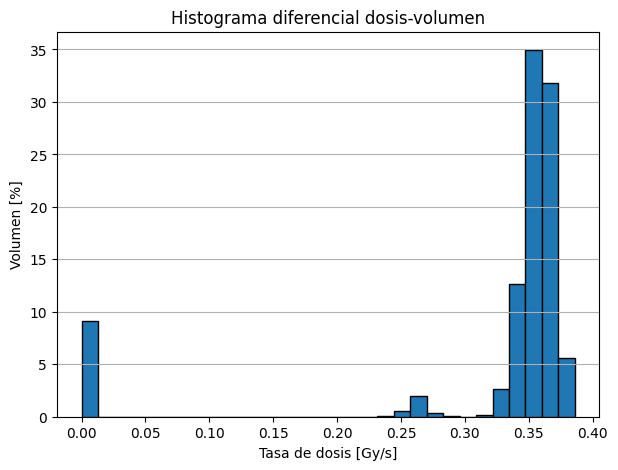

In [14]:
tiempo_seg = 1
data_dosis_fisica1sinat = data_dosis1sinat * tiempo_seg

n_bins = len(data_dosis_fisica1sinat)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica1sinat,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica1sinat) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [7]:
# MAXIMO DE DOSIS:
max_dosis = np.max(data_dosis_fisica1sinat)
print("Máximo de dosis:", max_dosis)

Máximo de dosis: 0.38595


In [8]:
np.std(data_dosis1sinat)/np.mean(data_dosis1sinat)
print(f"Coeficiente de variación sin sacar nada: {100*np.std(data_dosis1sinat)/np.mean(data_dosis1sinat):.2f}%")

Coeficiente de variación sin sacar nada: 32.17%


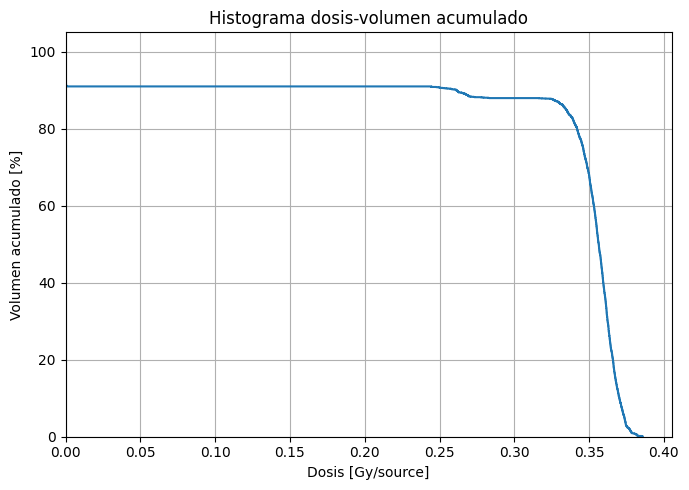

In [17]:
dosis = np.asarray(data_dosis1sinat)

dosis = dosis[np.isfinite(dosis)]

n_voxeles = len(dosis)

if n_voxeles == 0:
    raise ValueError("No hay datos de dosis.")

dosis_ordenada = np.sort(dosis)

dosis_unicas, indices = np.unique(
    dosis_ordenada,
    return_index=True
)

volumen_acumulado = 100.0 * (n_voxeles - indices) / n_voxeles

plt.figure(figsize=(7, 5))

plt.step(
    dosis_unicas,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")

plt.xlim(left=0)
plt.ylim(0, 105)
plt.grid(True)
plt.tight_layout()

plt.show()

In [18]:
archivo = "histograma_dosis_sinat.out"

nx = 16
ny = 33
nz = 4

xmin, xmax = -0.8, 0.8
ymin, ymax = -1.65, 1.65
zmin, zmax = 98.38, 98.58

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

dosissinat = np.full((nx, ny, nz), np.nan)
err_relsinat = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosissinat = float(partes[2])
            valor_errsinat = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosissinat[ix_actual, iy_actual, contador_z] = valor_dosissinat
            err_relsinat[ix_actual, iy_actual, contador_z] = valor_errsinat
            contador_z += 1

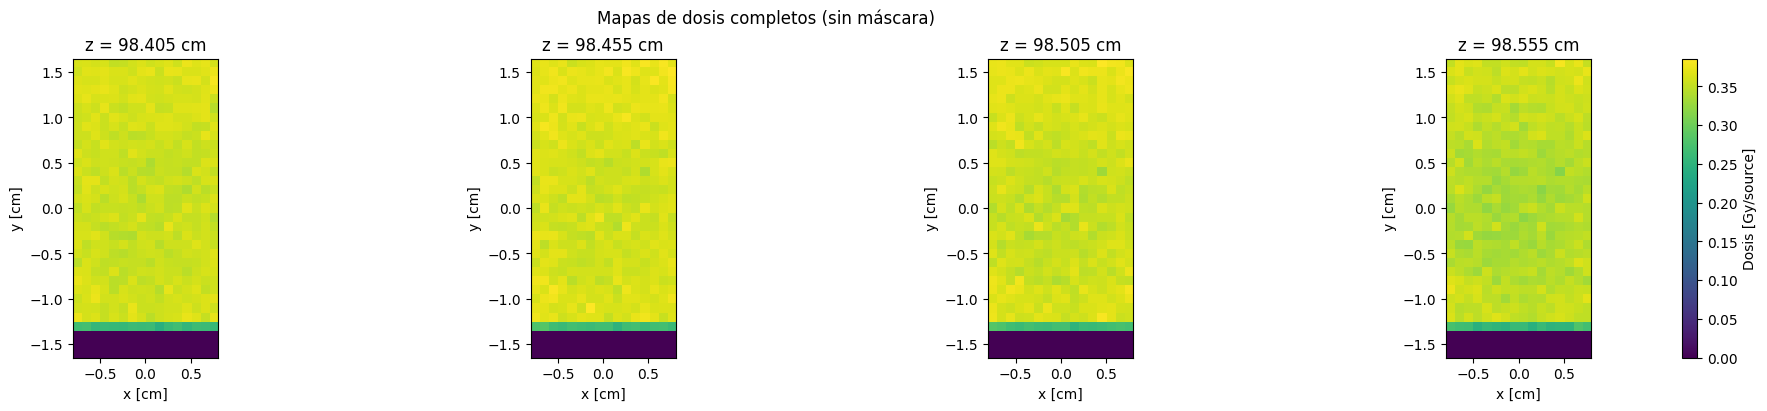

In [19]:
# ==========================================================
# MAPAS DE DOSIS SIN MÁSCARA
# ==========================================================

vmin = np.nanmin(dosissinat)
vmax = np.nanmax(dosissinat)

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

for iz in range(nz):

    im = axes[iz].imshow(
        dosissinat[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Mapas de dosis completos (sin máscara)")
plt.show()

In [20]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0

zmin_pouch = 98.38
zmax_pouch = 98.58
z0 = 0.5 * (zmin_pouch + zmax_pouch)

rx = 0.8
ry = 1.65
rz = 1.0

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin_pouch) & (Z <= zmax_pouch)

mascara_pouch = mascara_elipsoide & mascara_z

dosis_sin_airesinat = np.where(mascara_pouch, dosissinat, np.nan)
err_sin_airesinat = np.where(mascara_pouch, err_relsinat, np.nan)

data_dosis2sinat = dosis_sin_airesinat[~np.isnan(dosis_sin_airesinat)]

In [24]:

print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 1

dosis_sin_airesinat = np.where(mascara_pouch, dosissinat, np.nan)
err_sin_airesinat = np.where(mascara_pouch, err_relsinat, np.nan)

data_dosis2sinat = dosis_sin_airesinat[~np.isnan(dosis_sin_airesinat)]
data_dosis_fisica2sinat = data_dosis2sinat * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis2sinat))
print("Dosis mínima dentro del pouch [Gy/source]:", np.min(data_dosis2sinat))
print("Dosis máxima dentro del pouch [Gy/source]:", np.max(data_dosis2sinat))
print("Dosis mínima dentro del pouch [Gy]:", np.min(data_dosis_fisica2sinat))
print("Dosis máxima dentro del pouch [Gy]:", np.max(data_dosis_fisica2sinat))
print("Dosis media dentro del pouch [Gy]:", np.mean(data_dosis_fisica2sinat))

datossinat = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datossinat.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosissinat[ix, iy, iz],
                    dosissinat[ix, iy, iz] * tiempo_seg,
                    err_relsinat[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datossinat,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head(4)

z_centros:
[98.405 98.455 98.505 98.555]
Máscara pouch en la primera capa z:
[[False False False False False False False False False False False  True
   True  True  True  True  True  True  True  True  True  True False False
  False False False False False False False False False]
 [False False False False False False False  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True False False False False False False False]
 [False False False False False  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True False False False False False]
 [False False False  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  Tr

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.35955,0.35955,0.0180
1,1,12,2,-0.75,-0.5,98.455,0.36786,0.36786,0.0187
2,1,12,3,-0.75,-0.5,98.505,0.36697,0.36697,0.0200
3,1,12,4,-0.75,-0.5,98.555,0.35346,0.35346,0.0231


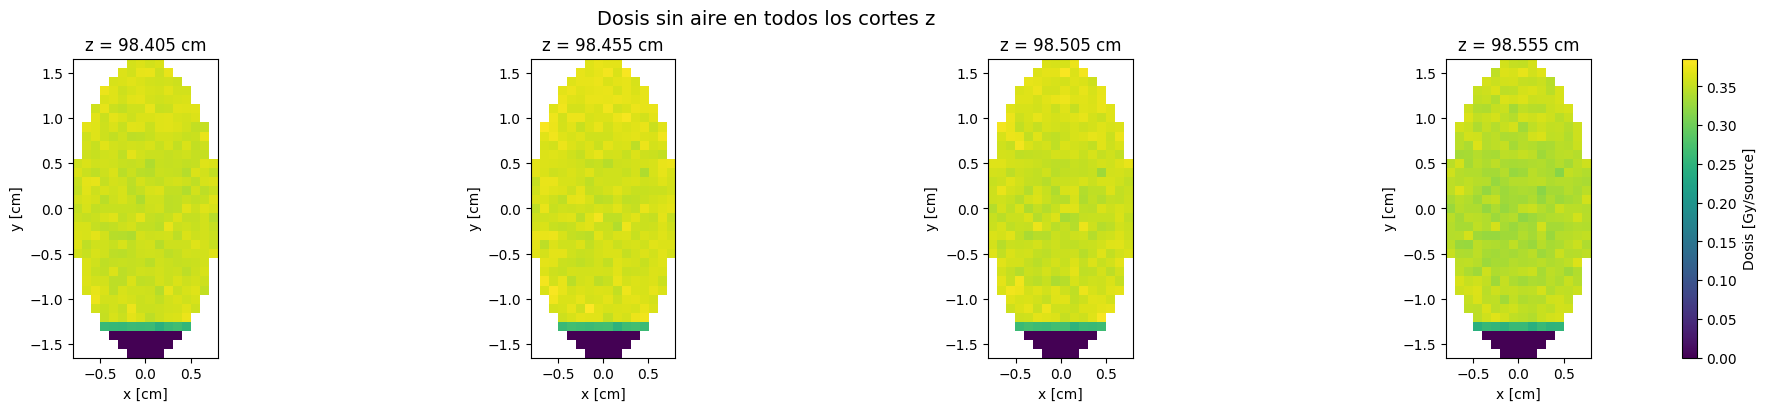

In [22]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_airesinat)
vmax = np.nanmax(dosis_sin_airesinat)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_airesinat[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

In [23]:
print(f"Dosis máxima = {np.max(dosis_ordenada1sinat ):.3f}Gy/source")

NameError: name 'dosis_ordenada1sinat' is not defined

In [16]:
ix_sacar = [0]
iy_sacar = [1,2,3]

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)
mascara_sacar[ix_sacar, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar

print("Vóxeles sacados:", np.sum(mascara_sacar))
print("Vóxeles pouch final:", np.sum(mascara_pouch))

Vóxeles sacados: 12
Vóxeles pouch final: 1648


In [17]:
mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin) & (Z <= zmax)

mascara_pouch = mascara_elipsoide & mascara_z

iy_sacar = [0,1,2,3]   # o [0,1,2,3]

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)

mascara_sacar[:, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar


print("Cantidad de voxeles dentro del pouch:", np.sum(mascara_pouch))

Cantidad de voxeles dentro del pouch: 1536


In [18]:
dosis_sin_airesinat = np.where(mascara_pouch, dosissinat, np.nan)
err_sin_airesinat = np.where(mascara_pouch, err_relsinat, np.nan)

data_dosissinat = dosis_sin_airesinat[~np.isnan(dosis_sin_airesinat)]
data_dosis_fisicasinat = data_dosissinat * tiempo_seg

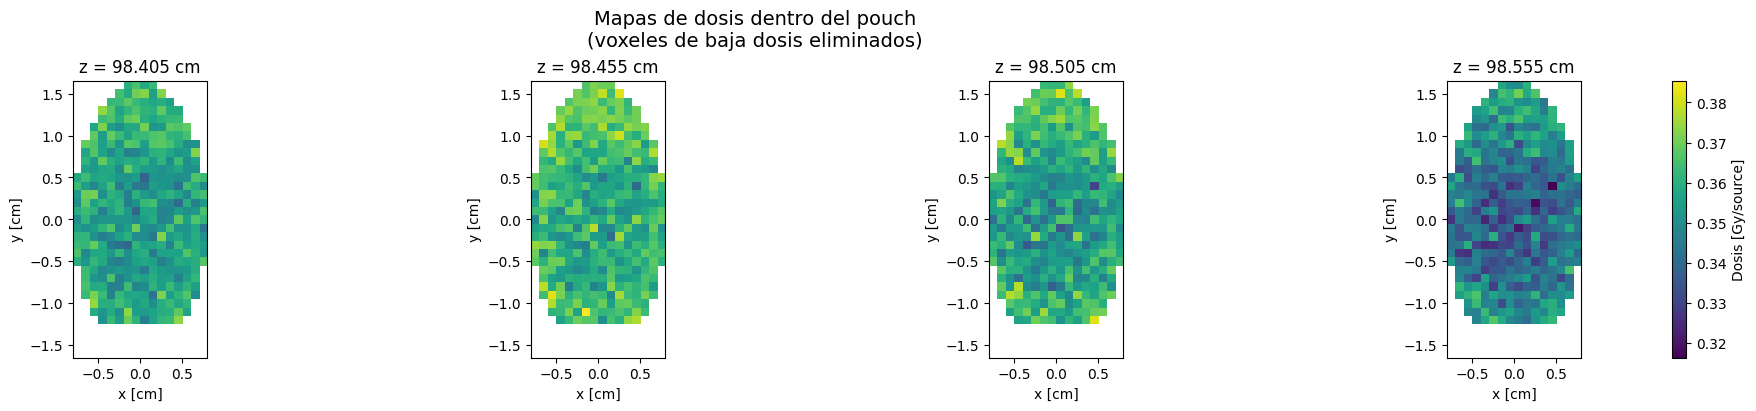

In [19]:
# ==========================================================
# MAPAS DE DOSIS CON LOS VOXELES DE BAJA DOSIS ELIMINADOS
# ==========================================================

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_airesinat)
vmax = np.nanmax(dosis_sin_airesinat)

for iz in range(nz):

    im = axes[iz].imshow(
        dosis_sin_airesinat[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm"
    )

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle(
    "Mapas de dosis dentro del pouch\n(voxeles de baja dosis eliminados)",
    fontsize=14
)

plt.show()

Cantidad de vóxeles usados: 1536
Dosis mínima [Gy]: 0.31637
Dosis máxima [Gy]: 0.38533
Dosis media [Gy]: 0.3558422591145833
Desvío estándar [Gy]: 0.010695980890086183
Coeficiente de variación [%]: 3.0058208703767293


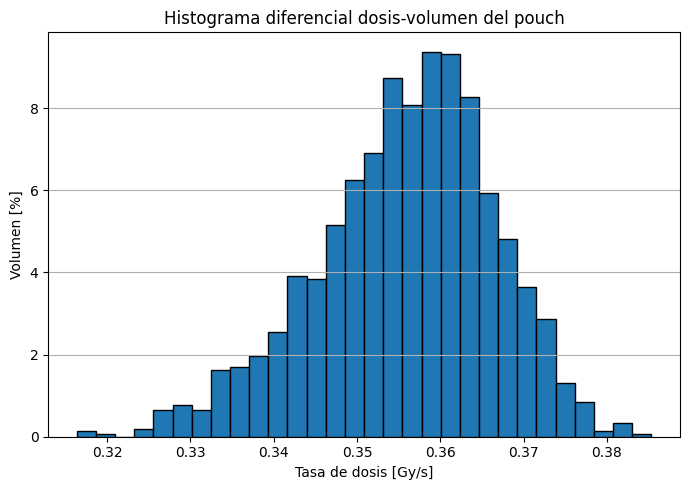

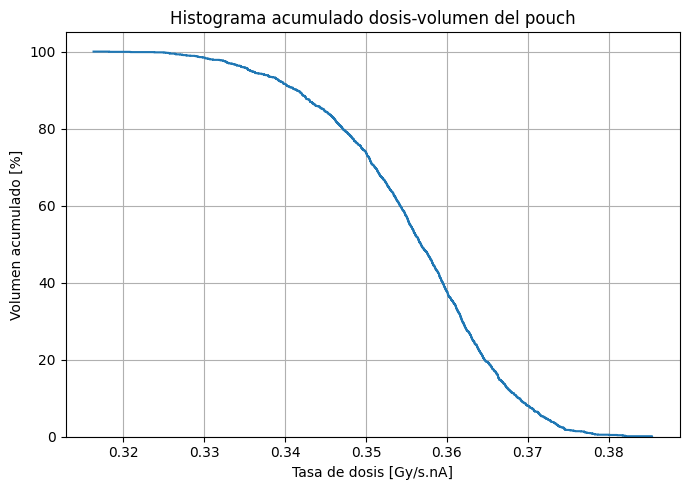

In [20]:
n_voxeles = len(data_dosis_fisicasinat)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

media = np.mean(data_dosis_fisicasinat)
desvio = np.std(data_dosis_fisicasinat)
cv = 100 * desvio / media

print("Cantidad de vóxeles usados:", n_voxeles)
print("Dosis mínima [Gy]:", np.min(data_dosis_fisicasinat))
print("Dosis máxima [Gy]:", np.max(data_dosis_fisicasinat))
print("Dosis media [Gy]:", media)
print("Desvío estándar [Gy]:", desvio)
print("Coeficiente de variación [%]:", cv)

bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisicasinat,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisicasinat) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

dosis_ordenadasinat = np.sort(data_dosis_fisicasinat)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenadasinat,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Tasa de dosis [Gy/s.nA]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")
plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Cantidad de vóxeles usados: 1536
Dosis mínima [Gy/(s·nA)]: 0.31637
Dosis máxima [Gy/(s·nA)]: 0.38533
Dosis media [Gy/(s·nA)]: 0.3558422591145833
Desvío estándar [Gy/(s·nA)]: 0.010695980890086183
Coeficiente de variación [%]: 3.0058208703767293


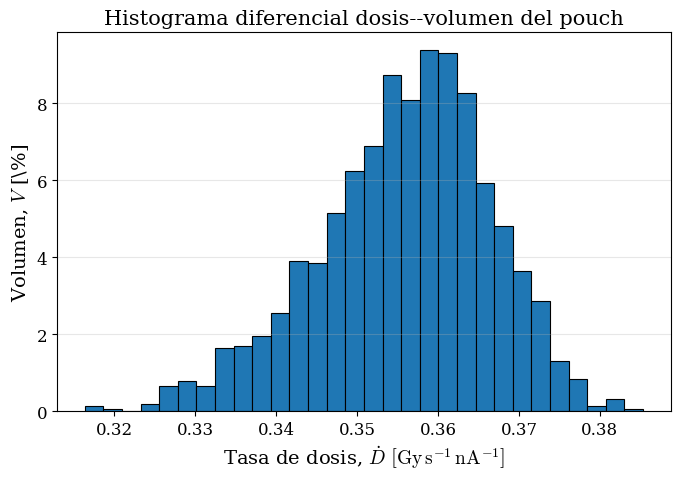

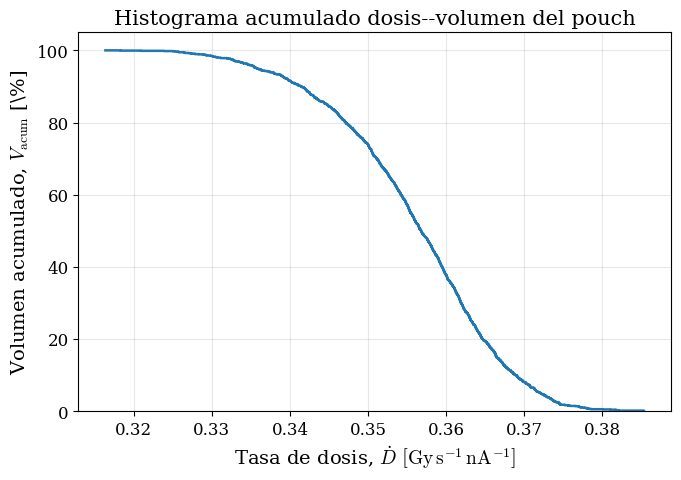

In [21]:

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

n_voxeles = len(data_dosis_fisicasinat)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

media = np.mean(data_dosis_fisicasinat)
desvio = np.std(data_dosis_fisicasinat)
cv = 100 * desvio / media

print("Cantidad de vóxeles usados:", n_voxeles)
print("Dosis mínima [Gy/(s·nA)]:", np.min(data_dosis_fisicasinat))
print("Dosis máxima [Gy/(s·nA)]:", np.max(data_dosis_fisicasinat))
print("Dosis media [Gy/(s·nA)]:", media)
print("Desvío estándar [Gy/(s·nA)]:", desvio)
print("Coeficiente de variación [%]:", cv)

bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisicasinat,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisicasinat) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel(
    r"Tasa de dosis, $\dot{D}$ "
    r"$\left[\mathrm{Gy}\,\mathrm{s}^{-1}\,\mathrm{nA}^{-1}\right]$"
)
plt.ylabel(r"Volumen, $V$ [\%]")
plt.title(r"Histograma diferencial dosis--volumen del pouch")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

dosis_ordenadasinat = np.sort(data_dosis_fisicasinat)
volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenadasinat,
    volumen_acumulado,
    where="post",
    linewidth=1.8
)

plt.xlabel(
    r"Tasa de dosis, $\dot{D}$ "
    r"$\left[\mathrm{Gy}\,\mathrm{s}^{-1}\,\mathrm{nA}^{-1}\right]$"
)
plt.ylabel(r"Volumen acumulado, $V_{\mathrm{acum}}$ [\%]")
plt.title(r"Histograma acumulado dosis--volumen del pouch")
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

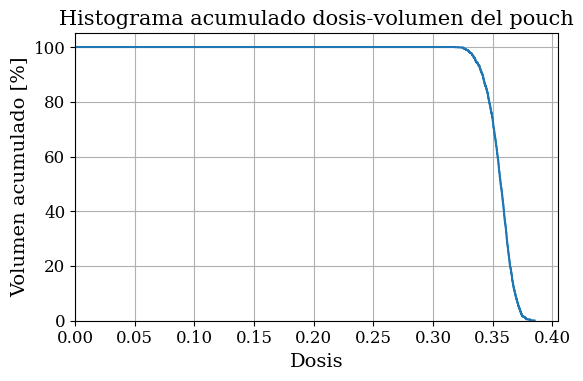

In [22]:
n_voxeles = len(data_dosis_fisicasinat)

dosis_ordenadasinat = np.sort(data_dosis_fisicasinat)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

dosis_acum_plotsinat = np.concatenate(([0.0], dosis_ordenadasinat))
volumen_acum_plot = np.concatenate(([100.0], volumen_acumulado))

plt.figure(figsize=(6, 4))

plt.step(
    dosis_acum_plotsinat,
    volumen_acum_plot,
    where="post"
)

plt.xlabel("Dosis")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")
plt.grid(True)
plt.xlim(0, np.max(data_dosis_fisicasinat) * 1.05)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

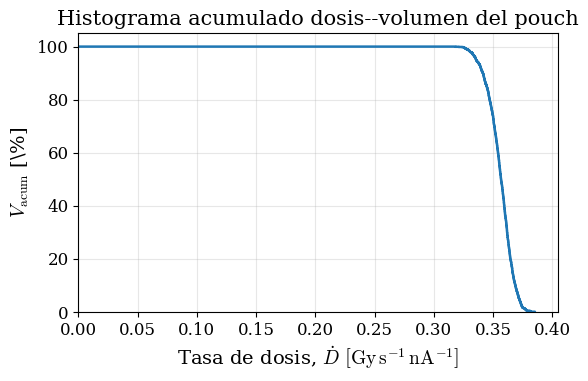

In [23]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

n_voxeles = len(data_dosis_fisicasinat)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

dosis_ordenadasinat = np.sort(data_dosis_fisicasinat)

volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

dosis_acum_plotsinat = np.concatenate((
    [0.0],
    dosis_ordenadasinat
))

volumen_acum_plot = np.concatenate((
    [100.0],
    volumen_acumulado
))

plt.figure(figsize=(6, 4))

plt.step(
    dosis_acum_plotsinat,
    volumen_acum_plot,
    where="post",
    linewidth=1.8
)

plt.xlabel(
    r"Tasa de dosis, $\dot{D}$ "
    r"$\left[\mathrm{Gy}\,\mathrm{s}^{-1}\,\mathrm{nA}^{-1}\right]$"
)

plt.ylabel(
    r"$V_{\mathrm{acum}}$ [\%]"
)

plt.title(
    r"Histograma acumulado dosis--volumen del pouch"
)

plt.grid(True, alpha=0.3)
plt.xlim(0, np.max(data_dosis_fisicasinat) * 1.05)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

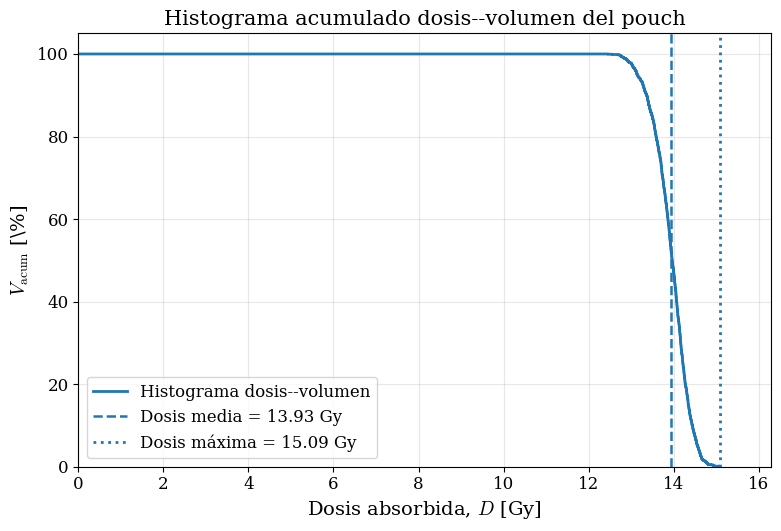

In [24]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

tiempo_irradiacion = 450.0
corriente = 0.087

data_dosis_finalsinat = (
    data_dosis_fisicasinat
    * tiempo_irradiacion
    * corriente
)

n_voxeles = len(data_dosis_finalsinat)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

dosis_media = np.mean(data_dosis_finalsinat)
dosis_maxima = np.max(data_dosis_finalsinat)

dosis_ordenadasinat = np.sort(data_dosis_finalsinat)

volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

dosis_acum_plotsinat = np.concatenate((
    [0.0],
    dosis_ordenadasinat
))

volumen_acum_plot = np.concatenate((
    [100.0],
    volumen_acumulado
))

plt.figure(figsize=(8, 5.5))

plt.step(
    dosis_acum_plotsinat,
    volumen_acum_plot,
    where="post",
    linewidth=2.0,
    label="Histograma dosis--volumen"
)

plt.axvline(
    dosis_media,
    linestyle="--",
    linewidth=1.8,
    label=rf"Dosis media = {dosis_media:.2f} Gy"
)

plt.axvline(
    dosis_maxima,
    linestyle=":",
    linewidth=2.0,
    label=rf"Dosis máxima = {dosis_maxima:.2f} Gy"
)

plt.xlabel(
    r"Dosis absorbida, $D$ [Gy]"
)

plt.ylabel(
    r"$V_{\mathrm{acum}}$ [\%]"
)

plt.title(
    r"Histograma acumulado dosis--volumen del pouch"
)

plt.grid(True, alpha=0.3)
plt.xlim(0, dosis_maxima * 1.08)
plt.ylim(0, 105)
plt.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

In [25]:
print(f"Dosis máxima = {np.max(data_dosis_fisicasinat):.3f} Gy")

Dosis máxima = 0.385 Gy


Gráfico para la presentacion final

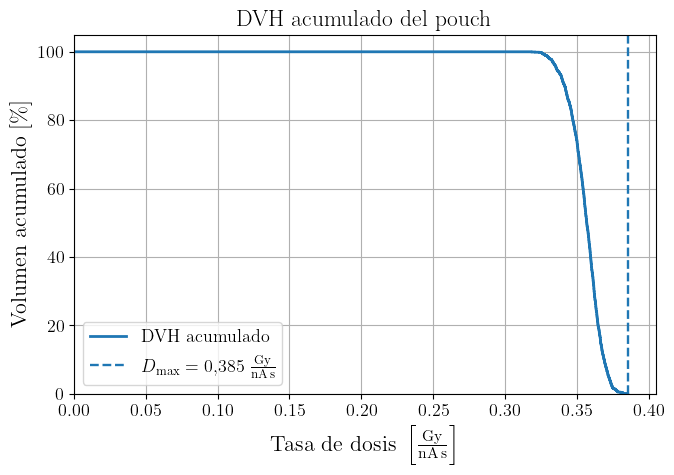

In [26]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

n_voxeles = len(data_dosis_fisicasinat)

dosis_ordenadasinat = np.sort(data_dosis_fisicasinat)

volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

dosis_acum_plotsinat = np.concatenate((
    [0.0],
    dosis_ordenadasinat
))

volumen_acum_plot = np.concatenate((
    [100.0],
    volumen_acumulado
))

dosis_maxima = np.max(data_dosis_fisicasinat)

dosis_maxima_texto = (
    f"{dosis_maxima:.3f}"
    .replace(".", "{,}")
)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_acum_plotsinat,
    volumen_acum_plot,
    where="post",
    linewidth=2,
    label=r"$\mathrm{DVH\ acumulado}$"
)

plt.axvline(
    dosis_maxima,
    linestyle="--",
    linewidth=1.7,
    label=(
        rf"$D_{{\mathrm{{max}}}}="
        rf"{dosis_maxima_texto}\;"
        rf"\frac{{\mathrm{{Gy}}}}{{\mathrm{{nA}}\,\mathrm{{s}}}}$"
    )
)

plt.xlabel(
    r"$\mathrm{Tasa \ de \ dosis}\;"
    r"\left[\frac{\mathrm{Gy}}{\mathrm{nA}\,\mathrm{s}}\right]$"
)

plt.ylabel(
    r"$\mathrm{Volumen\ acumulado}\;[\%]$"
)

plt.title(
    r"$\mathrm{DVH\ acumulado\ del\ pouch}$"
)

plt.grid(True)
plt.legend()

plt.xlim(0, dosis_maxima * 1.05)
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

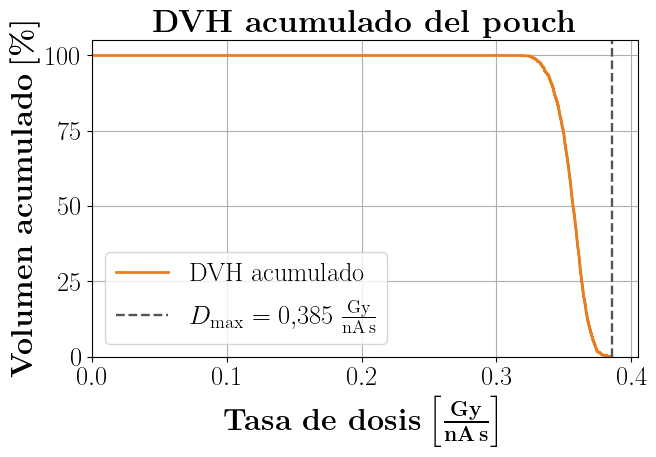

In [34]:
plt.rcdefaults()

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "serif",
    "font.size": 21,
    "axes.titlesize": 23,
    "axes.labelsize": 22,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 19
})

n_voxeles = len(data_dosis_fisicasinat)

dosis_ordenadasinat = np.sort(data_dosis_fisicasinat)

volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

dosis_acum_plotsinat = np.concatenate((
    [0.0],
    dosis_ordenadasinat
))

volumen_acum_plot = np.concatenate((
    [100.0],
    volumen_acumulado
))

dosis_maxima = np.max(data_dosis_fisicasinat)

dosis_maxima_texto = (
    f"{dosis_maxima:.3f}"
    .replace(".", "{,}")
)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_acum_plotsinat,
    volumen_acum_plot,
    where="post",
    linewidth=2,
    color="#E67E22",
    label="DVH acumulado"
)

plt.axvline(
    dosis_maxima,
    color="#555555",
    linestyle="--",
    linewidth=1.7,
    label=(
        rf"$D_{{\mathrm{{max}}}}="
        rf"{dosis_maxima_texto}\;"
        rf"\frac{{\mathrm{{Gy}}}}{{\mathrm{{nA}}\,\mathrm{{s}}}}$"
    )
)

plt.xlabel(
    r"\textbf{Tasa de dosis}\;"
    r"$\boldsymbol{\left[\frac{\mathrm{Gy}}{\mathrm{nA}\,\mathrm{s}}\right]}$"
)

plt.ylabel(
    r"\textbf{Volumen acumulado}\;"
    r"$\boldsymbol{[\%]}$"
)

plt.title(r"\textbf{DVH acumulado del pouch}")

plt.grid(True)
plt.legend()

plt.xlim(0, dosis_maxima * 1.05)
plt.ylim(0, 105)

plt.tight_layout()
plt.show()